In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
import math

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Метрики оценки моделей
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [ ]:

df = pd.read_csv("hypertension_dataset.csv")

# 2. Очистка и предварительная обработка данных
# Заполняем пропуски в столбце 'Medication' значением 'None' (если пациент не принимает медикаменты)
df['Medication'] = df['Medication'].fillna('None')

# Преобразуем категорию истории давления в числовую шкалу:
# Normal -> 0, Prehypertension -> 1, Hypertension -> 2.
bp_history_mapping = {'Normal': 0, 'Prehypertension': 1, 'Hypertension': 2}
df['BP_History'] = df['BP_History'].map(bp_history_mapping)

# Кодируем категориальные признаки с помощью one-hot (dummy variables).
# drop_first=True убирает одну колонку из каждой группы, чтобы избежать мультиколлинеарности.
# dtype=int делает результат явным целочисленным типом.
categorical_cols = ['Family_History', 'Exercise_Level', 'Smoking_Status', 'Medication']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# Преобразуем целевую переменную в числовую: Yes -> 1, No -> 0
df['Has_Hypertension'] = df['Has_Hypertension'].map({'Yes': 1, 'No': 0})


In [ ]:
# Список колонок, которые удалим из признаков (включая целевой, если он присутствует в этом списке).
cols_to_drop = [col for col in [
    'Medication_Beta Blocker',
    'Medication_Other',
    'Medication_None',
    'Exercise_Level_Moderate',
    'Exercise_Level_Low',
    'Has_Hypertension'
] if col in df.columns]

# Формируем X (признаки) и y (целевая переменная)
X = df.drop(cols_to_drop, axis=1)
y = df['Has_Hypertension']

In [ ]:
# Разбиваем данные на обучающую и тестовую выборки.
# stratify=y сохраняет пропорции классов в разбиении при дисбалансе классов.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# Стандартизация признаков:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Инициализация классификаторов
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "SVM (Linear)": SVC(kernel='linear', probability=True, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "KNN (k=10)": KNeighborsClassifier(n_neighbors=10),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Naive Bayes": GaussianNB()
}

In [ ]:
results = []
roc_curves = {}

for name, model in classifiers.items():
    print(f"\nОбучение и оценка: {name}")
    try:
        model.fit(X_train_scaled, y_train)
    except Exception as e:
        print(f"Ошибка при обучении {name}: {e}")
        continue

    # Предсказанные метки
    y_pred = model.predict(X_test_scaled)

    # --- Начало вывода метрик по отдельности ---


    # Precision / Recall / F1
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred, average='binary', zero_division=0
    )

    # --- Конец вывода метрик по отдельности ---

    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)

    # Попытка получить скор/вероятности для ROC-AUC
    y_score = None
    try:
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test_scaled)[:, 1]
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_test_scaled)
    except Exception as e:
        print(f"  Ошибка при получении скора для {name}: {e}")
        y_score = None

    roc_auc = None
    fpr = tpr = thresholds = None
    if y_score is not None:
        try:
            roc_auc = roc_auc_score(y_test, y_score)
            fpr, tpr, thresholds = roc_curve(y_test, y_score)
            roc_curves[name] = (fpr, tpr, roc_auc)
        except Exception as e:
            print(f"  Ошибка при расчёте ROC AUC для {name}: {e}")
            roc_auc = None
    else:
        print(f"  Модель {name} не возвращает predict_proba/decision_function — ROC AUC пропущен.")

    results.append({
        "model": name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "roc_auc": roc_auc

    })


Обучение и оценка: Logistic Regression

Обучение и оценка: SVM (Linear)

Обучение и оценка: SVM (RBF)

Обучение и оценка: Decision Tree

Обучение и оценка: KNN (k=5)

Обучение и оценка: KNN (k=10)

Обучение и оценка: Random Forest

Обучение и оценка: Naive Bayes


In [ ]:
# Собираем результаты в DataFrame и сортируем по F1
results_df = pd.DataFrame(results).sort_values(by='f1', ascending=False).reset_index(drop=True)
print("\nСводная таблица результатов:")
print(results_df[['model', 'precision', 'recall', 'f1', 'roc_auc']])



Сводная таблица результатов:
                 model  precision    recall        f1   roc_auc
0        Random Forest   0.957346  0.980583  0.968825  0.994866
1        Decision Tree   0.961353  0.966019  0.963680  0.962067
2            SVM (RBF)   0.919192  0.883495  0.900990  0.964545
3            KNN (k=5)   0.923497  0.820388  0.868895  0.951914
4          Naive Bayes   0.844340  0.868932  0.856459  0.941798
5           KNN (k=10)   0.946429  0.771845  0.850267  0.953464
6  Logistic Regression   0.837438  0.825243  0.831296  0.919738
7         SVM (Linear)   0.837438  0.825243  0.831296  0.920627


## Вывод:
На основе метрик, Random Forest является наилучшей моделью для решения данной задачи классификации. Она демонстрирует самые высокие значения F1-score и ROC AUC, что указывает на ее  высокую общую производительность. Decision Tree также является сильным кандидатом, показывая очень хорошие результаты.

Модели SVM (RBF) и KNN (k=5) показывают приемлемые, но не выдающиеся результаты.

Модели Naive Bayes, KNN (k=10), Logistic Regression и SVM (Linear) являются наименее эффективными.

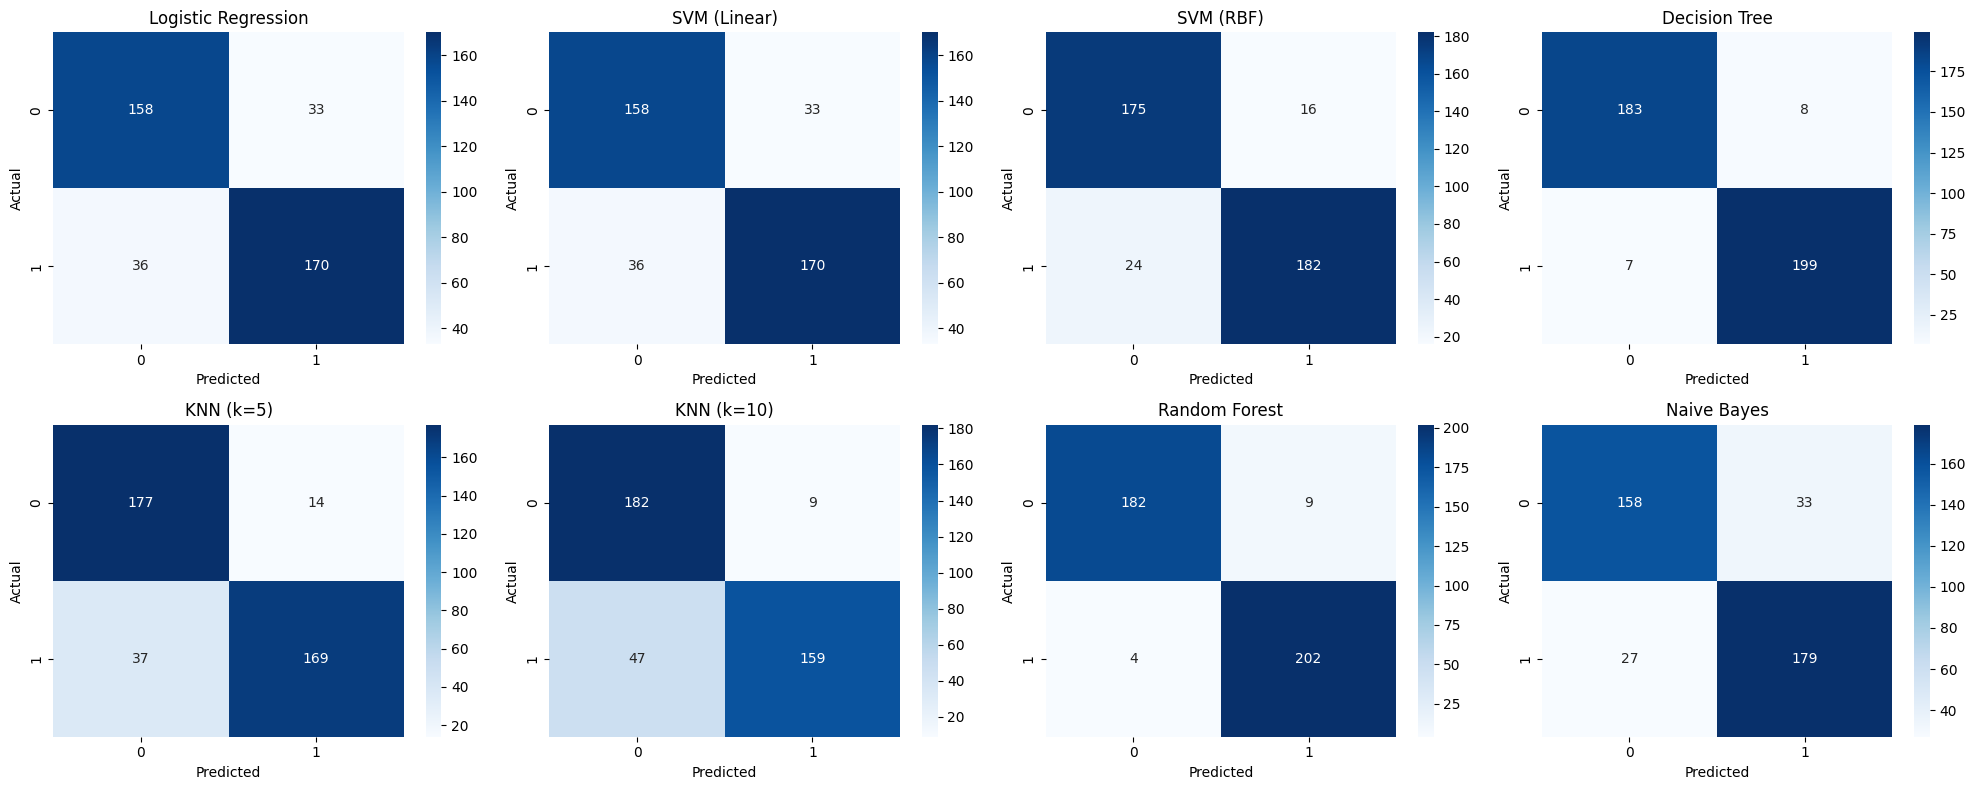

In [ ]:
# Визуализация матриц ошибок
n = len(results)
cols = 4
rows = int(np.ceil(n / cols))
plt.figure(figsize=(cols*5, rows*4))
for i, res in enumerate(results):
    ax = plt.subplot(rows, cols, i+1)
    cm = res['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(res['model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## Анализ:
Logistic Regression / SVM (Linear)
TN = 158, FP = 33, FN = 36, TP = 170.
Обе модели дают одинаковые результаты — умеренно сбалансированная работа, без сильного смещения в сторону precision или recall.

SVM (RBF)
TN = 175, FP = 16, FN = 24, TP = 182.
Заметно лучше, чем линейные модели — хороший баланс, меньше ошибок обоих типов.

Decision Tree
TN = 183, FP = 8, FN = 7, TP = 199.

Очень высокие показатели на этих данных; дерево обнаруживает положительный класс почти без пропусков (FN=7).

KNN (k=5)
TN = 177, FP = 14, FN = 37, TP = 169.
Высокая precision (мало ложноположительных), но хуже recall — теряем больше истинных положительных.

KNN (k=10)
TN = 182, FP = 9, FN = 47, TP = 159.
Ещё выше precision, но ещё хуже recall (много FN).

Random Forest
TN = 182, FP = 9, FN = 4, TP = 202.
Наилучший результат по всем ключевым метрикам (очень низкое количество FN — 4).

Naive Bayes
TN = 158, FP = 33, FN = 27, TP = 179.
Средние показатели, модель простая и быстрая, но уступает RF/DT/SVM (RBF).


При выборе модели для задачи классификации, особенно в контексте медицинской диагностики, важно учитывать последствия пропуска больного (ложноотрицательных случаев, FN). В данном случае, чем меньше FN, тем лучше, так как это означает, что меньшее количество больных не будет диагностировано.

## Вывод:
На основании анализа, лучшим выбором будет Random Forest, так как он имеет наименьшее количество ложных отрицательных случаев (FN = 4), что означает, что он наилучшим образом справляется с задачей минимизации пропусков. Decision Tree также показывает хорошие результаты (FN = 7), но Random Forest обеспечивает большую стабильность и предсказуемость за счёт ансамблевого подхода.


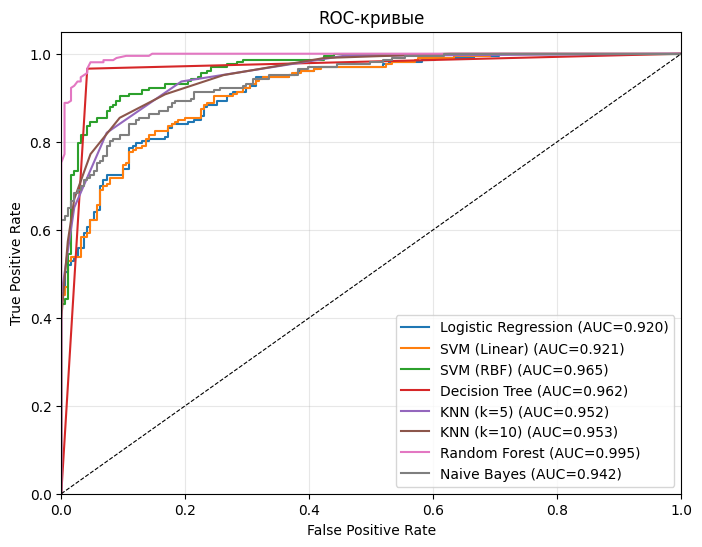

In [ ]:
# Визуализация ROC-кривых всех моделей
if len(roc_curves) > 0:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 6))
    cmap = plt.colormaps['tab10']
    discrete_colors = getattr(cmap, 'colors', None)

    n = len(roc_curves)
    for i, (name, (fpr, tpr, roc_auc)) in enumerate(roc_curves.items()):
        if discrete_colors is not None:
            color = discrete_colors[i % len(discrete_colors)]
        else:
            color = cmap(i / max(1, n - 1))
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", color=color)

    plt.plot([0, 1], [0, 1], 'k--', lw=0.8)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривые')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Нет доступных ROC-кривых (отсутствуют predict_proba/decision_function).")



## Анализ:
Все модели демонстрируют хорошую способность ранжировать объекты (AUC ≥ 0.920).
Лучший результат — Random Forest (AUC = 0.995) — почти идеальная ROC-кривая, затем SVM (RBF) 0.965 и Decision Tree 0.962.
Наименее сильные — Logistic Regression (0.920) и линейный SVM (0.921), но всё ещё прилично.

## Вывод:
Лучший результат — Random Forest (AUC = 0.995) — почти идеальная ROC-кривая.

## Итог:
### Random Forest является наилучшей моделью для решения данной задачи классификации.